In [ ]:
import torch
import torch.nn as nn

In [ ]:
def double(x):
    return 2 * x

In [ ]:
def triple(x):
    return 3*x

In [ ]:
def calc_number(func , x):
    return func(x)

In [ ]:
calc_number(double , 2)

In [ ]:
def get_multiple_func(n): # 返回一个函数。根据前面的参数确定返回函数的类型

    def multiple(x):
        return x * x
    return multiple

In [ ]:
double  = get_multiple_func(2)
triple = get_multiple_func(3)

In [ ]:
double(3)

In [ ]:
def dec(func):
    return 1

@dec
def dec_double(x):
    # dec_double = dec(dec_double)
    return x*2


print(x == dec_double)
print(dec_double)



In [ ]:
def hi ( name = " yasoob " ) :
     return " hi " + name 
print ( hi ( ) )


def hi(name = " yasoob "):
     print("现在你在hi()函数之中")
     def greet():
        print("现在你在greet()函数之中")
     def welcome():
        print("现在你在welcome()函数之中")

hi()

In [ ]:
def hi(name=" yasoob "):
    def greet():
        return "现在你在greet()函数中"

    def welcome():
        return "现在你在welcome()函数中"

    if name == " yasoob ":
        return greet
    else:
        return welcome
    

def hi():
    return "hi yasoob!"
def doSomethingBeforeHi ( func ) :
    print( "在执行 hi() 之前，我正在做一些无聊的工作")
    print(func())
    
doSomethingBeforeHi(hi)

In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import sys
import os
sys.path.append('./FWQ/ultralytics-main')


In [15]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'  # 替换为你选择的字体

In [4]:
model = YOLO("FWQ/ultralytics-main/results/11_yolo11n-seg-DenseSkip-C3K2_LS-PID/weights/best.pt")
torch_model = model.model
torch_model.eval()

SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): C3k2_LS(
      (cv1): Conv(
        (conv): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(8, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(8, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (m): ModuleList()
      (cv3): Conv(
        (conv): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inp

In [5]:
feature_maps = {}

In [6]:
def get_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

该层共有 16 个通道，特征图尺寸: 160x160
✅ 全通道平均热力图已保存: layer6_mean_overlay.jpg
✅ 对比图(原图|热力图|叠加)已保存: layer6_mean_compare.jpg


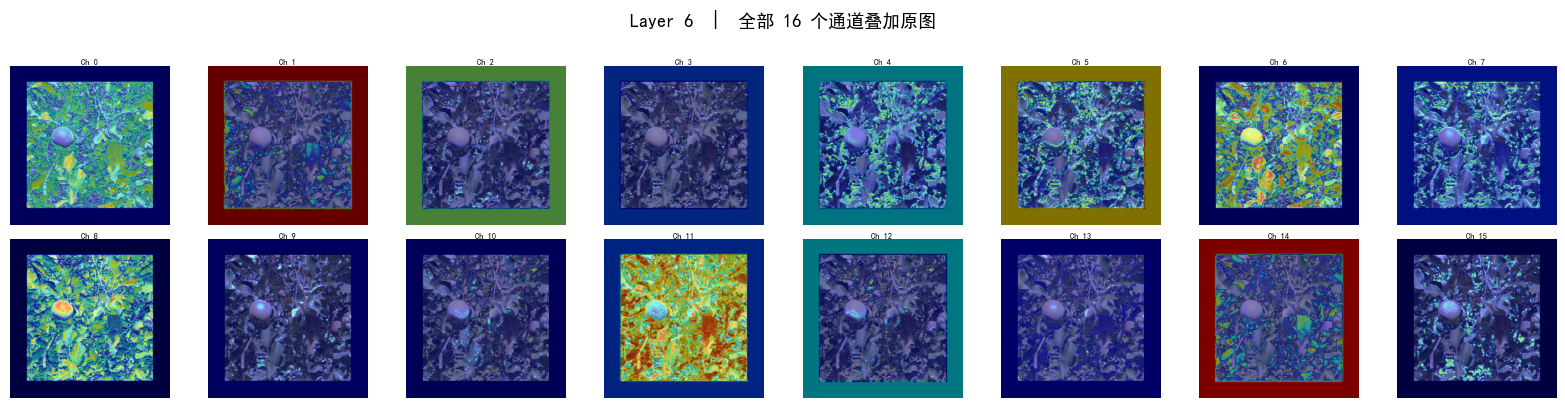

In [36]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

TARGET_LAYER_IDX =6 # 修改为你想观察的层
hook = torch_model.model[TARGET_LAYER_IDX].register_forward_hook(
    get_hook(f"layer_{TARGET_LAYER_IDX}")
)

img_path = "data/Apple_RGB_D_Amoal/yolo/train/images/_MG_7095_08.png"
depth_path = "data/Apple_RGB_D_Amoal/depth_pic/_MG_7095_08.png"

img_bgr = cv2.imread(img_path)
assert img_bgr is not None, f"RGB图片读取失败: {img_path}"
depth_bgr = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)
assert depth_bgr is not None, f"深度图读取失败: {depth_path}"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))
depth_resized = cv2.resize(depth_bgr, (640, 640))

img_float = img_resized.astype(np.float32) / 255.0
depth_float = depth_resized.astype(np.float32) / 255.0

input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0)
depth_tensor = torch.from_numpy(depth_float).unsqueeze(0).unsqueeze(0)
input_4ch = torch.cat([input_tensor, depth_tensor], dim=1)

with torch.no_grad():
    _ = torch_model(input_4ch)

hook.remove()

# ════════════════════════════════════════════════════════
# 工具函数
# ════════════════════════════════════════════════════════
def fmap_to_heatmap_bgr(feature_map_2d, target_size=(640, 640)):
    """将单通道特征图转成彩色热力图 (BGR, uint8)"""
    fm = feature_map_2d.numpy() if isinstance(feature_map_2d, torch.Tensor) else feature_map_2d
    fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
    fm_uint8 = (fm * 255).astype(np.uint8)
    fm_resized = cv2.resize(fm_uint8, target_size)
    heatmap_bgr = cv2.applyColorMap(fm_resized, cv2.COLORMAP_JET)
    return heatmap_bgr

def overlay(img_bgr_orig, heatmap_bgr, alpha=0.5):
    """热力图叠加原图"""
    orig = cv2.resize(img_bgr_orig, (heatmap_bgr.shape[1], heatmap_bgr.shape[0]))
    return cv2.addWeighted(orig, 1 - alpha, heatmap_bgr, alpha, 0)

# ════════════════════════════════════════════════════════
# ① 全通道平均热力图 → 叠加原图（最直观，看这层整体关注啥）
# ════════════════════════════════════════════════════════
fmap = feature_maps[f"layer_{TARGET_LAYER_IDX}"][0]  # [C, H, W]
num_channels = fmap.shape[0]
print(f"该层共有 {num_channels} 个通道，特征图尺寸: {fmap.shape[1]}x{fmap.shape[2]}")

mean_fmap = fmap.mean(dim=0)  # [H, W] 所有通道取平均

heatmap_mean = fmap_to_heatmap_bgr(mean_fmap)
overlaid_mean = overlay(img_bgr, heatmap_mean, alpha=0.5)

cv2.imwrite(f"layer{TARGET_LAYER_IDX}_mean_overlay.jpg", overlaid_mean)
print(f"✅ 全通道平均热力图已保存: layer{TARGET_LAYER_IDX}_mean_overlay.jpg")

# 顺便也保存一张原图+热力图并排对比
compare = np.hstack([
    cv2.resize(img_bgr, (640, 640)),
    heatmap_mean,
    overlaid_mean
])
cv2.imwrite(f"layer{TARGET_LAYER_IDX}_mean_compare.jpg", compare)
print(f"✅ 对比图(原图|热力图|叠加)已保存: layer{TARGET_LAYER_IDX}_mean_compare.jpg")

# ════════════════════════════════════════════════════════
# ② 每个通道单独叠加原图（大图，适合细看每通道关注点）
# ════════════════════════════════════════════════════════
# N = min(64, num_channels)   # 最多显示64个，太多图会很大
N = num_channels  # ← 全部通道
cols = 8
rows = (N + cols - 1) // cols
cell_size = max(1.0, min(2.0, 512 / num_channels))

fig, axes = plt.subplots(rows, cols, figsize=(cols * cell_size, rows * cell_size))
if rows == 1: axes = axes[np.newaxis, :]
if cols == 1: axes = axes[:, np.newaxis]

fig.suptitle(
    f"Layer {TARGET_LAYER_IDX}  |  全部 {N} 个通道叠加原图",
    fontsize=13, y=1.01
)

for i in range(rows * cols):
    ax = axes[i // cols][i % cols]
    ax.axis('off')
    if i >= N:
        continue
    heatmap_bgr = fmap_to_heatmap_bgr(fmap[i])
    overlaid_bgr = overlay(img_bgr, heatmap_bgr, alpha=0.5)
    overlaid_rgb = cv2.cvtColor(overlaid_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(overlaid_rgb)
    ax.set_title(f"Ch {i}", fontsize=6, pad=1)

plt.tight_layout()
plt.savefig(f"layer{TARGET_LAYER_IDX}_ALL_channels.jpg", dpi=100, bbox_inches='tight')
plt.show()